In [1]:
import re
import traceback
import pandas as pd
import numpy as np
from scipy import stats
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D

# 文件路径
WT_path = "/mnt/sunxh/hela_dataset/predict.m11wt.tsv"
KO_path = "/mnt/sunxh/hela_dataset/predict.m11ko.tsv"
gtf_path = "/mnt/sunxh/hela_dataset/GCF_000001405.40_GRCh38.p14_genomic.gtf"
fasta_path = "/mnt/sunxh/hela_dataset/GRCh38_latest_rna.fna" 

id_dict = {}
with open(gtf_path) as f:
    for line in f:
        if line.startswith("#"):
            continue
        fields = line.strip().split("\t")
        if len(fields) < 9:
            continue
        attr_field = fields[8]
        
 
        transcript_match = re.search(r'transcript_id "([^"]+)"', attr_field)
        gene_match = re.search(r'gene "([^"]+)"', attr_field)
        
        if transcript_match and gene_match:
            transcript_id = transcript_match.group(1).split('.')[0] 
            gene_name = gene_match.group(1)
            id_dict[transcript_id] = gene_name



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict


probability_cutoff = 0.9 
coverage_threshold = 10 

gtf_path = "/mnt/sunxh/hela_dataset/GCF_000001405.40_GRCh38.p14_genomic.gtf"


gtf_columns = ['seqname', 'source', 'feature', 'start', 'end', 
               'score', 'strand', 'frame', 'attribute']


gtf_df = pd.read_csv(
    gtf_path, 
    sep='\t', 
    comment='#', 
    header=None, 
    names=gtf_columns,
    dtype={'attribute': str}
)


gtf_df = gtf_df[gtf_df['feature'] == 'transcript']


def parse_attributes(attr_str):

    attributes = {}
    parts = attr_str.strip().split(';')
    for part in parts:
        if part.strip() == '': continue
        key_value = part.strip().split(' ', 1)
        if len(key_value) == 2:
            key = key_value[0].strip()
 
            value = key_value[1].strip().replace('"', '')
            attributes[key] = value
    return attributes

gtf_df['attributes_dict'] = gtf_df['attribute'].apply(parse_attributes)

gtf_df['transcript_id'] = gtf_df['attributes_dict'].apply(lambda x: x.get('transcript_id', None))
gtf_df['gene_name'] = gtf_df['attributes_dict'].apply(lambda x: x.get('gene', None))


transcript_to_gene = gtf_df.dropna(subset=['transcript_id']).set_index('transcript_id')['gene_name'].to_dict()



In [13]:
print("示例解析后的属性字段：")
print(gtf_df['attributes_dict'].head(5).tolist())


示例解析后的属性字段：
[{'gene_id': 'DDX11L1', 'transcript_id': 'NR_046018.2', 'db_xref': 'HGNC:HGNC:37102', 'gbkey': 'misc_RNA', 'gene': 'DDX11L1', 'product': 'DEAD/H-box helicase 11 like 1 (pseudogene)', 'pseudo': 'true', 'transcript_biotype': 'transcript'}, {'gene_id': 'WASH7P', 'transcript_id': 'NR_024540.1', 'db_xref': 'HGNC:HGNC:38034', 'gbkey': 'misc_RNA', 'gene': 'WASH7P', 'product': 'WASP family homolog 7, pseudogene', 'pseudo': 'true', 'transcript_biotype': 'transcript'}, {'gene_id': 'MIR6859-1', 'transcript_id': 'NR_106918.1', 'db_xref': 'miRBase:MI0022705', 'gbkey': 'precursor_RNA', 'gene': 'MIR6859-1', 'product': 'microRNA 6859-1', 'transcript_biotype': 'primary_transcript'}, {'gene_id': 'MIR6859-1', 'transcript_id': 'unassigned_transcript_1', 'db_xref': 'miRBase:MI0022705', 'gbkey': 'ncRNA', 'gene': 'MIR6859-1', 'product': 'hsa-miR-6859-3p', 'transcript_biotype': 'miRNA'}, {'gene_id': 'MIR6859-1', 'transcript_id': 'unassigned_transcript_2', 'db_xref': 'miRBase:MI0022705', 'gbkey': '

In [8]:

def process_prediction_file(file_path):

    site_data = defaultdict(lambda: {'total_reads': 0, 'mod_reads': 0})
    
    with open(file_path, 'r') as f:
        for line in f:
            fields = line.strip().split("\t")
            if len(fields) < 6:
                continue
                
            transcript_id = fields[0]
            position = int(fields[1])
            mod_prob = float(fields[5])
            
 
            site_key = (transcript_id, position)
            
 
            site_data[site_key]['total_reads'] += 1
            if mod_prob > probability_cutoff:
                site_data[site_key]['mod_reads'] += 1
                
 
    site_df = pd.DataFrame([
        {
            'transcript_id': key[0],
            'position': key[1],
            'total_reads': data['total_reads'],
            'mod_reads': data['mod_reads'],
            'mod_fraction': data['mod_reads'] / data['total_reads'] if data['total_reads'] > 0 else 0
        }
        for key, data in site_data.items()
    ])
    
 
    site_df = site_df[site_df['total_reads'] >= coverage_threshold]
    
    return site_df



wt_site_df = process_prediction_file('/mnt/sunxh/hela_dataset/predict.m11wt.tsv')

ko_site_df = process_prediction_file('/mnt/sunxh/hela_dataset/predict.m11ko.tsv')



处理WT样本预测文件...
处理KO样本预测文件...


In [9]:

def calculate_transcript_mod_rate(site_df):

 
    site_df['is_mod'] = site_df['mod_fraction'] > 0.1
    
 
    transcript_df = site_df.groupby('transcript_id').agg(
        total_sites=('is_mod', 'count'),
        mod_sites=('is_mod', 'sum')
    ).reset_index()
    
    transcript_df['mod_rate'] = transcript_df['mod_sites'] / transcript_df['total_sites']
    
    return transcript_df

print("计算WT转录本修饰率...")
wt_transcript = calculate_transcript_mod_rate(wt_site_df)
print("计算KO转录本修饰率...")
ko_transcript = calculate_transcript_mod_rate(ko_site_df)


计算WT转录本修饰率...
计算KO转录本修饰率...


In [10]:

print("合并数据...")
merged_df = pd.merge(
    wt_transcript[['transcript_id', 'mod_rate']],
    ko_transcript[['transcript_id', 'mod_rate']],
    on='transcript_id',
    suffixes=('_wt', '_ko'),
    how='inner' 
)


merged_df['gene_name'] = merged_df['transcript_id'].map(transcript_to_gene)


merged_df['mod_diff'] = merged_df['mod_rate_wt'] - merged_df['mod_rate_ko']
merged_df['abs_diff'] = merged_df['mod_diff'].abs()


合并数据...


In [11]:
from scipy.stats import fisher_exact


merged_df = pd.merge(
    wt_transcript[['transcript_id', 'mod_sites', 'total_sites']],
    ko_transcript[['transcript_id', 'mod_sites', 'total_sites']],
    on='transcript_id',
    suffixes=('_wt', '_ko'),
    how='inner'
)


merged_df['gene_name'] = merged_df['transcript_id'].map(transcript_to_gene)


merged_df['mod_rate_wt'] = merged_df['mod_sites_wt'] / merged_df['total_sites_wt']
merged_df['mod_rate_ko'] = merged_df['mod_sites_ko'] / merged_df['total_sites_ko']
merged_df['mod_diff'] = merged_df['mod_rate_wt'] - merged_df['mod_rate_ko']
merged_df['abs_diff'] = merged_df['mod_diff'].abs()


pvalues = []
for _, row in merged_df.iterrows():
 
    table = [
        [row['mod_sites_wt'], row['total_sites_wt'] - row['mod_sites_wt']],
        [row['mod_sites_ko'], row['total_sites_ko'] - row['mod_sites_ko']]
    ]
    _, p = fisher_exact(table)
    pvalues.append(p)

merged_df['pvalue'] = pvalues
from statsmodels.stats.multitest import multipletests


rejected, pvals_corrected, _, _ = multipletests(merged_df['pvalue'], method='fdr_bh')
merged_df['qvalue'] = pvals_corrected
merged_df['significant'] = rejected


In [12]:
output_csv = '/mnt/sunxh/hela_dataset/transcript_modification_rates_with_fisher.csv'
merged_df.to_csv(output_csv, index=False)
print(f"处理完成! 共 {len(merged_df)} 个转录本的数据（含Fisher检验）")
print(f"结果已保存至: {output_csv}")


处理完成! 共 1661 个转录本的数据（含Fisher检验）
结果已保存至: /mnt/sunxh/hela_dataset/transcript_modification_rates_with_fisher.csv


In [14]:
import pandas as pd

gtf_path = "/mnt/sunxh/hela_dataset/GCF_000001405.40_GRCh38.p14_genomic.gtf"
gtf_columns = ['seqname', 'source', 'feature', 'start', 'end', 
               'score', 'strand', 'frame', 'attribute']
gtf_df = pd.read_csv(gtf_path, sep='\t', comment='#', header=None, names=gtf_columns)


def parse_attributes(attr_str):
    attributes = {}
    parts = attr_str.strip().split(';')
    for part in parts:
        if part.strip() == '':
            continue
        key_value = part.strip().split(' ', 1)
        if len(key_value) == 2:
            key = key_value[0].strip()
            value = key_value[1].strip().replace('"', '')
            attributes[key] = value
    return attributes

gtf_df['attributes_dict'] = gtf_df['attribute'].apply(parse_attributes)
gtf_df['transcript_id'] = gtf_df['attributes_dict'].apply(lambda x: x.get('transcript_id'))
gtf_df['gene_name'] = gtf_df['attributes_dict'].apply(
    lambda x: x.get('gene') or x.get('gene_name') or x.get('gene_id')
)


gtf_df['transcript_id_nover'] = gtf_df['transcript_id'].str.split('.').str[0]
transcript_to_gene = gtf_df.dropna(subset=['transcript_id_nover']).drop_duplicates('transcript_id_nover').set_index('transcript_id_nover')['gene_name'].to_dict()


In [15]:

input_file = "/mnt/sunxh/hela_dataset/transcript_modification_rates_with_fisher.csv"
df = pd.read_csv(input_file)


df['transcript_id_nover'] = df['transcript_id'].str.split('.').str[0]


df['gene_name'] = df.apply(
    lambda row: transcript_to_gene.get(row['transcript_id_nover'], row['gene_name']), axis=1
)


df.drop(columns=['transcript_id_nover'], inplace=True)


output_file = "/mnt/sunxh/hela_dataset/transcript_modification_rates_with_fisher_annotated.csv"
df.to_csv(output_file, index=False)
print(f"已完成 gene_name 补全，结果保存至: {output_file}")


已完成 gene_name 补全，结果保存至: /mnt/sunxh/hela_dataset/transcript_modification_rates_with_fisher_annotated.csv


/mnt/sunxh/miniconda3/envs/TandemMod/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 4 x 3 in image.
/mnt/sunxh/miniconda3/envs/TandemMod/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: /mnt/sunxh/sunxh/wattmamba/figure/supfig7_hela_gene.pdf


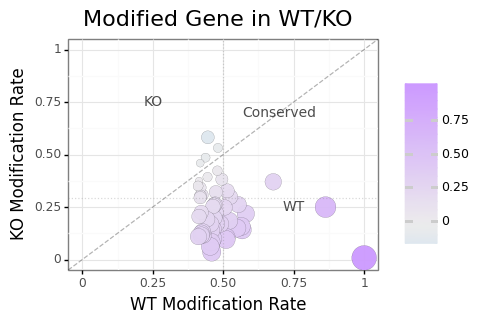

In [67]:
from plotnine import *
import pandas as pd
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.size'] = 8
top_40 = df.nlargest(50, 'mod_rate_wt').copy()


top_40['diff_norm'] = (top_40['abs_diff'] - top_40['abs_diff'].min()) / (top_40['abs_diff'].max() - top_40['abs_diff'].min())

p = (
    ggplot(top_40, aes(x='mod_rate_wt', y='mod_rate_ko')) +
    geom_point(
        aes(size='diff_norm', fill='mod_diff'),
        color='black',
        stroke=0.05, 
        alpha=0.95
    ) +
    scale_fill_gradient2( 
        low='#89C4FF',
        mid='#ECECEC',
        high='#CC99FF',
        midpoint=0
    ) +
    scale_size_continuous(range=[3, 10]) +
    geom_abline(slope=1, intercept=0, linetype='dashed', color='black', alpha=0.3) +
    geom_vline(xintercept=top_40['mod_rate_wt'].max()/2, linetype='dotted', color='gray', alpha=0.3) +
    geom_hline(yintercept=top_40['mod_rate_ko'].max()/2, linetype='dotted', color='gray', alpha=0.3) +
    annotate('text', x=0.75, y=0.25, label='WT', size=10, color='black', alpha=0.7, family="Arial") +
    annotate('text', x=0.25, y=0.75, label='KO', size=10, color='black', alpha=0.7, family="Arial") +
    annotate('text', x=0.7, y=0.7, label='Conserved', size=10, color='black', alpha=0.7, family="Arial") +
    labs(
        title='Modified Gene in WT/KO',
        x='WT Modification Rate',
        y='KO Modification Rate',
        fill='', 
        size='|WT-KO|'
    ) +
    xlim(0, 1) +
    ylim(0, 1) +
    theme_bw() +
    theme(
        text=element_text(family="Arial"),
        plot_title=element_text(size=16),
        axis_title=element_text(size=12),
        legend_title=element_text(size=11),
        legend_text=element_text(size=9),
        figure_size=[4,3],

    ) +
    guides(size=False) 
)
p.save(
    filename='/mnt/sunxh/sunxh/wattmamba/figure/supfig7_hela_gene.pdf',dpi=900,
)
print(p)

/mnt/sunxh/miniconda3/envs/TandemMod/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 12 x 3.0 in image.
/mnt/sunxh/miniconda3/envs/TandemMod/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: /mnt/sunxh/sunxh/wattmamba/figure/supfig7_hela_gene_heatmap.pdf


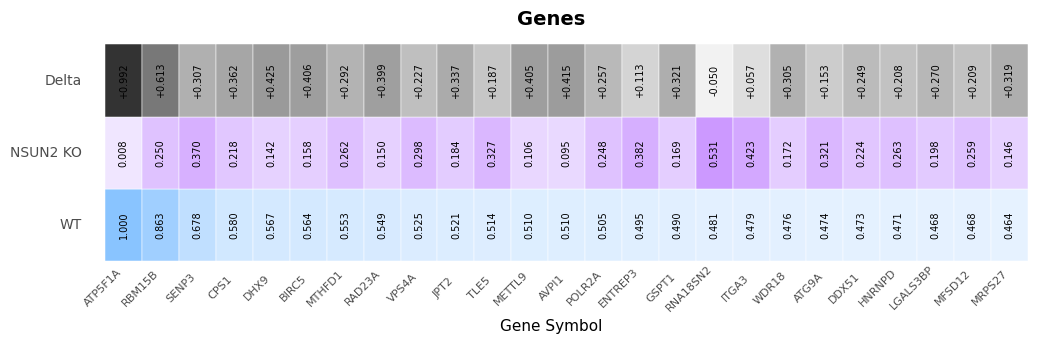

In [106]:
from plotnine import *
import pandas as pd
c1 = "#89C4FF" 
c2 = "#CC99FF" 

top_genes = df.nlargest(25, 'mod_rate_wt')


heatmap_data = top_genes[['gene_name', 'mod_rate_wt', 'mod_rate_ko']].copy()
heatmap_data.columns = ['gene_name', 'WT', 'NSUN2 KO'] 
heatmap_data['Delta'] = heatmap_data['WT'] - heatmap_data['NSUN2 KO']
heatmap_long = pd.melt(
    heatmap_data,
    id_vars='gene_name',
    value_vars=['WT', 'NSUN2 KO', 'Delta'],
    var_name='Metric',
    value_name='Value'
)

# 创建注释标签列
heatmap_long['label'] = heatmap_long.apply(
    lambda row: f"{row['Value']:+.3f}" if row['Metric'] == 'Delta' else f"{row['Value']:.3f}",
    axis=1
)


heatmap_long['Metric'] = pd.Categorical(
    heatmap_long['Metric'],
    categories=['WT', 'NSUN2 KO', 'Delta'],
    ordered=True
)


heatmap_long['gene_name'] = pd.Categorical(
    heatmap_long['gene_name'],
    categories=heatmap_data.sort_values('WT', ascending=False)['gene_name'],
    ordered=True
)
heatmap_long = heatmap_long[heatmap_long['Metric'].notnull() & heatmap_long['label'].notnull()]

c1 = "#89C4FF"  
c2 = "#CC99FF" 
c3 = "#BBBBBB" 
def scale_value(val, min_val, max_val):

    if pd.isnull(val):
        return 0
    return (val - min_val) / (max_val - min_val) if max_val != min_val else 0

def interpolate_color(low_rgb, high_rgb, alpha):

    return tuple(int(l + (h - l) * alpha) for l, h in zip(low_rgb, high_rgb))

def rgb_to_hex(rgb):
    return '#{:02X}{:02X}{:02X}'.format(*rgb)


color_map = {
    'WT': ('#E6F2FF', '#89C4FF'), 
    'NSUN2 KO': ('#F0E6FF', '#CC99FF'), 
    'Delta': ('#F2F2F2', '#333333'), 
}


fill_colors = []
for _, row in heatmap_long.iterrows():
    metric = row['Metric']
    value = row['Value']
    min_val = heatmap_long.loc[heatmap_long['Metric'] == metric, 'Value'].min()
    max_val = heatmap_long.loc[heatmap_long['Metric'] == metric, 'Value'].max()
    alpha = scale_value(value, min_val, max_val)
    low_rgb = tuple(int(color_map[metric][0].lstrip("#")[i:i+2], 16) for i in (0, 2, 4))
    high_rgb = tuple(int(color_map[metric][1].lstrip("#")[i:i+2], 16) for i in (0, 2, 4))
    fill_color = rgb_to_hex(interpolate_color(low_rgb, high_rgb, alpha))
    fill_colors.append(fill_color)

heatmap_long['fill_color'] = fill_colors
p = (
    ggplot(heatmap_long, aes(x='gene_name', y='Metric')) + 
    geom_tile(aes(fill='fill_color'), color='white', size=0.2) +
    geom_text(aes(label='label'), size=7, family="Arial",angle=90) + 
    scale_fill_identity() +
    labs(
        title='Genes',
        x='Gene Symbol',
        y='' 

    ) +
    theme_minimal() +
    theme(
        figure_size=(12, 3.), 
        axis_text_x=element_text(rotation=45, hjust=1,vjust=0.8, size=8),
        axis_text_y=element_text(size=10),
        text=element_text(family="Arial"),
        plot_title=element_text(size=14, weight='bold'),
        axis_title=element_text(size=11),
        legend_position='none',
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
    )
)
p.save(
    filename='/mnt/sunxh/sunxh/wattmamba/figure/supfig7_hela_gene_heatmap.pdf',
    dpi=900,
)
print(p)

In [108]:
import re

WT_path = "/mnt/sunxh/hela_dataset/predict.m11wt.tsv"

site_dict = {}

with open(WT_path) as f:
    for line in f:
        line = line.rstrip()
        id = "|".join(line.split("\t")[0:3])
        probability = float(line.split("\t")[5])
        if id not in site_dict:
            site_dict[id] = [0, 0]
        if probability > 0.98:
            site_dict[id][0] += 1
        site_dict[id][1] += 1

motif_dict = {}
for id in site_dict:
    motif = id.split("|")[2]
    if motif not in motif_dict:
        motif_dict[motif] = [0, 0]
    if site_dict[id][1] < 5:
        continue
    if site_dict[id][0] / site_dict[id][1] >= 0.5:
        motif_dict[motif][0] += 1
    motif_dict[motif][1] += 1

diff_mod_dict = {}
for motif in motif_dict:
    diff_mod_dict[motif] = motif_dict[motif][0] / motif_dict[motif][1]


kmer_filter = "[ACGT]{2}C[ACGT]{2}"

motifs = []
diff_mod_rates = []
NNCNN = []


for motif in diff_mod_dict:
    if diff_mod_dict[motif] > 0.010:
        motifs.append(motif)
        diff_mod_rates.append(diff_mod_dict[motif])
        if len([x.start() for x in re.finditer(kmer_filter, motif)]) == 0:
            NNCNN.append(motif)

print(f"共有 {len(motifs)} 个motif满足修饰比例大于0.01的条件")

共有 134 个motif满足修饰比例大于0.01的条件


In [ ]:
top10 = sorted(diff_mod_dict.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"\n共有 {len(motifs)} 个motif满足修饰比例大于0.01的条件")
print("修饰比例最高的前10个motif如下：")
for i, (motif, ratio) in enumerate(top10, 1):
    print(f"{i}. {motif}: {ratio:.3f}")

共有 134 个motif满足修饰比例大于0.01的条件

共有 134 个motif满足修饰比例大于0.01的条件
修饰比例最高的前10个motif如下：
1. GTCAC: 0.047
2. TTCAC: 0.044
3. CACAC: 0.042
4. CTCAC: 0.037
5. CACAA: 0.035
6. TTCGC: 0.034
7. CACAG: 0.034
8. CACTT: 0.033
9. GACTC: 0.033
10. TTCGA: 0.030


In [112]:
from collections import defaultdict
import numpy as np


base_pos_prob_dict = defaultdict(list)
for motif, prob in diff_mod_dict.items():
    if len(motif) != 5:
        continue
    for i, base in enumerate(motif):
        if base in 'ACGT':
            base_pos_prob_dict[(base, i)].append(prob)


base_pos_avg_prob = {}
for (base, pos), prob_list in base_pos_prob_dict.items():
    base_pos_avg_prob[(base, pos)] = np.mean(prob_list)

base_pos_normalized = {}
for pos in range(5):
    total = sum(base_pos_avg_prob.get((base, pos), 0) for base in 'ACGT')
    for base in 'ACGT':
        raw = base_pos_avg_prob.get((base, pos), 0)
        base_pos_normalized[(base, pos)] = raw / total if total > 0 else 0


print("每种碱基在5-mer每个位点的标准化修饰概率（按位点归一化，和为1）：")
print("位置\tA\tC\tG\tT")
for i in range(5):
    line = [f"{base_pos_normalized.get((base, i), 0):.4f}" for base in 'ACGT']
    print(f"{i+1}\t" + "\t".join(line))



每种碱基在5-mer每个位点的标准化修饰概率（按位点归一化，和为1）：
位置	A	C	G	T
1	0.1885	0.2794	0.2579	0.2741
2	0.3252	0.1641	0.1666	0.3441
3	0.0000	1.0000	0.0000	0.0000
4	0.3103	0.1699	0.2350	0.2849
5	0.2458	0.3202	0.1856	0.2483


findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif


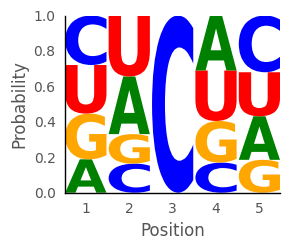

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import logomaker

df_logo = []
for pos in range(5):
    row = {base: base_pos_normalized.get((base, pos), 0) for base in ['A', 'C', 'G', 'U']}
    df_logo.append(row)
df_logo = pd.DataFrame(df_logo)
df_logo.index = range(1, 6)

fig, ax = plt.subplots(figsize=(3, 2.6), facecolor='none') 
ax.set_facecolor('white') 

logo = logomaker.Logo(
    df_logo,
    ax=ax,
    font_name='Arial',
    color_scheme='classic'
)


ax.set_xlabel("Position", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=10)
ax.set_ylim([0, 1])
ax.tick_params(axis='both', labelsize=10)

ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_color("black")

ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1)
ax.spines['left'].set_color("black")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)

plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/figure/supfig7_hela_logo.pdf", dpi=900)

plt.show()

